# Projet de classification d'image de cellules afin de détecter le parasite de la Malaria

**Auteurs :** Capucine Schmidt, Clément Le Boulaire, Noé Vermaut

## I. Initialisation et imports

In [9]:
import os
import sys
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image

sys.path.append(os.path.abspath(".."))

import Module.Pre_traitement as pre_traitement
import Module.MLP as mlp
import Module.Evaluation as eval
import Module.Application as app 
import Module.Affichages as aff

PROJET_RACINE = os.path.abspath("..")


UNINFECTED_PATH = os.path.join(PROJET_RACINE, "Data", "Uninfected")
PARASITIZED_PATH = os.path.join(PROJET_RACINE, "Data", "Parasitized")

## II. Chargement des données et Analyse Exploratoire (EDA)
Nous chargeons les images, les redimensionnons (32x32), et extrayons un vecteur hybride contenant à la fois les pixels et 8 descripteurs.

Extraction des caractéristiques pour 1000 images par classe...
Dataset chargé : 2000 images, 1032 variables par image.


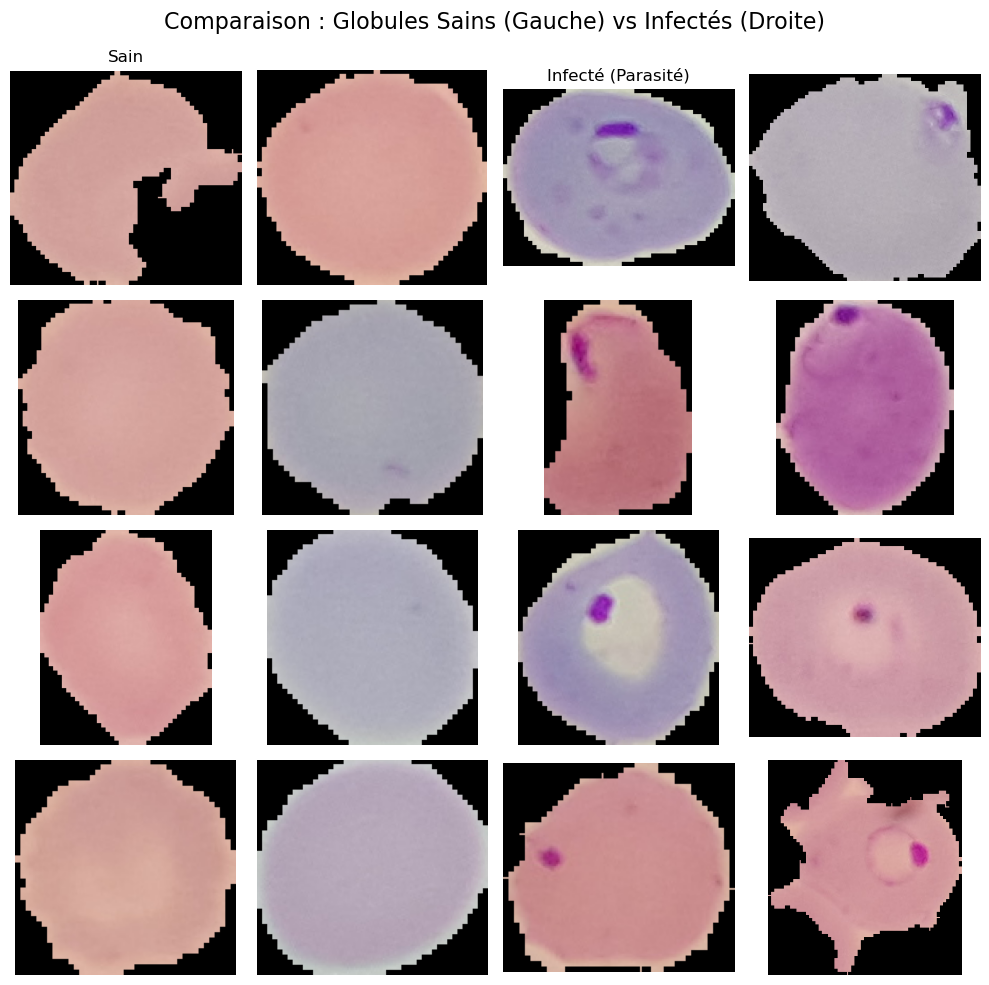

In [10]:
print(f"Extraction des caractéristiques pour {mlp.MAX_IMAGES} images par classe...")

data, target = mlp.load_images(
    uninfected_dir=UNINFECTED_PATH,
    parasitized_dir=PARASITIZED_PATH,
    image_size=mlp.TAILLE_IMAGE,
    max_per_class=mlp.MAX_IMAGES
)

print(f"Dataset chargé : {data.shape[0]} images, {data.shape[1]} variables par image.")

# Affichage de quelques échantillons
aff.plot_image_grid(UNINFECTED_PATH, PARASITIZED_PATH)

## II. Modèle MLP avec mini-Batch
### Recherche des meilleurs hyperparamètres pour le réseau

In [11]:
best, all_results = mlp.random_search_hyperparameters(
    data=data,
    target=target,
    train_func=mlp.mlp_fit_minibatch,
    predict_func=mlp.predict_relu,
    hidden_layer_configs=[[32, 16], [64, 32], [128, 64]],
    batch_sizes=[16, 32, 64],
    learning_rate_range=(0.001, 0.05),
    n_trials=10,
    random_state=42
)


TRIAL 1/10
hidden_layers : [32, 16]
batch_size    : 64
learning_rate : 0.005567
--- Fold 1/3 ---
Accuracy fold 1 : 0.4933 | Loss : 0.4442
--- Fold 2/3 ---
Accuracy fold 2 : 0.5247 | Loss : 0.3955
--- Fold 3/3 ---
Accuracy fold 3 : 0.4820 | Loss : 0.4230

Accuracy moyenne : 0.5000
→ accuracy = 0.5000
PRUNED

TRIAL 2/10
hidden_layers : [64, 32]
batch_size    : 64
learning_rate : 0.015304
--- Fold 1/3 ---
Accuracy fold 1 : 0.4933 | Loss : 0.2409
--- Fold 2/3 ---
Accuracy fold 2 : 0.5247 | Loss : 0.2110
--- Fold 3/3 ---
Accuracy fold 3 : 0.4820 | Loss : 0.2371

Accuracy moyenne : 0.5000
→ accuracy = 0.5000
PRUNED

TRIAL 3/10
hidden_layers : [32, 16]
batch_size    : 16
learning_rate : 0.045452
--- Fold 1/3 ---
    -> Early Stopping à l'époque 33 (Loss opt: 0.1646)
Accuracy fold 1 : 0.4933 | Loss : 0.2563
--- Fold 2/3 ---
    -> Early Stopping à l'époque 22 (Loss opt: 0.2207)
Accuracy fold 2 : 0.5247 | Loss : 0.4611
--- Fold 3/3 ---
Accuracy fold 3 : 0.4820 | Loss : 0.2188

Accuracy moyenne

In [12]:
best_lr_minibatch = best["learning_rate"]
best_hidden_layers_minibatch = best["hidden_layers"]
best_batch_size_minibatch = best["batch_size"]

modele_minibatch = mlp.cross_validation(data, target, mlp.mlp_fit_minibatch, mlp.predict_relu, n_folds=5, learning_rate=best_lr_minibatch, hidden_layer_sizes=best_hidden_layers_minibatch, batch_size=best_batch_size_minibatch)

TypeError: 'NoneType' object is not subscriptable

## IV. Évaluation (Cross-Validation K-Fold)
En utilisant les meilleurs hyperparamètres trouvés, nous évaluons la robustesse de notre modèle via une Validation Croisée à 5 plis. À l'intérieur de la boucle de validation, nous appliquons une ACP ciblée uniquement sur les pixels pour réduire le bruit tout en conservant nos descripteurs experts.

In [13]:
print(f"Exécution de la Cross-Validation avec la meilleure configuration : {best['hidden_layers']}")

cv_results = mlp.cross_validation(
    data=data, 
    target=target, 
    train_func=mlp.mlp_fit_minibatch_ultime, 
    predict_func=mlp.predict_relu, 
    n_folds=5, 
    learning_rate=best["learning_rate"], 
    hidden_layer_sizes=best["hidden_layers"], 
    batch_size=best["batch_size"],
    random_state=42
)

TypeError: 'NoneType' object is not subscriptable

### 4.1. Analyse des Métriques Cliniques
Le Rappel (Recall) est notre métrique principale : on cherche à minimiser les Faux Négatifs (malades non détectés).

In [ ]:
# Extraction de la matrice globale depuis le dictionnaire retourné
mc_globale = cv_results["confusion_matrix"]

acc = eval.exactitude(mc_globale)
prec = eval.precision(mc_globale)
rap = eval.rappel(mc_globale)
f1 = eval.score_f1(prec, rap)

print("=== RAPPORT CLINIQUE ===")
print(f"Exactitude (Accuracy) : {acc:.4f}")
print(f"Précision             : {prec:.4f}")
print(f"Rappel (Recall)       : {rap:.4f}  <-- Indicateur critique")
print(f"Score F1              : {f1:.4f}")

# Transformation en array numpy pour l'affichage graphique
cm_array = np.array([[mc_globale['VN'], mc_globale['FP']], 
                     [mc_globale['FN'], mc_globale['VP']]])

plt.figure(figsize=(5, 5))
eval.plot_confusion_matrix(cm_array, classes=['Saines', 'Infectées'], normalize=True)
plt.show()

NameError: name 'cv_results' is not defined

## V. Entraînement pour la Production et Sauvegarde
L'architecture étant validée, nous réentraînons le réseau sur **100 % des données** afin de déployer l'application finale.

In [ ]:
# 1. Normalisation globale
mean_final = np.mean(data, axis=0)
std_final = np.std(data, axis=0)
std_final = np.where(std_final < 1e-8, 1e-8, std_final)
data_scaled = np.clip((data - mean_final) / std_final, -5, 5)

# 2. Séparation Pixels / Experts
n_pixels = mlp.TAILLE_IMAGE[0] * mlp.TAILLE_IMAGE[1]
data_pixels = data_scaled[:, :n_pixels]
data_experts = data_scaled[:, n_pixels:]

# 3. ACP de production
pca_final = mlp.PCA(n_components=mlp.COMPOSANTES_PCA, random_state=42)
data_pixels_pca = pca_final.fit_transform(data_pixels)

# 4. Fusion
data_production = np.concatenate([data_pixels_pca, data_experts], axis=1)

# 5. Entraînement
w_final, b_final, losses = mlp.mlp_fit_minibatch_ultime(
    data_production, target, 
    n_epochs=mlp.EPOCHS, 
    hidden_layer_sizes=best["hidden_layers"],
    learning_rate=best["learning_rate"], 
    batch_size=best["batch_size"], 
    random_state=42, 
    dropout_rate=mlp.TAUX_DROPOUT, 
    patience=mlp.PATIENCE, 
    lambda_reg=mlp.LAMBDA_L2
)

# Affichage de la convergence finale
aff.plot_losses(losses, title="Convergence du Modèle de Production (Loss)")

# 6. Sauvegarde
app.save_model("modele_malaria.npz", w_final, b_final, mean_final, std_final, pca_final.components_, pca_final.mean_)
print("Modèle 'modele_malaria.npz' sauvegardé avec succès.")

## VI. Démonstration de l'Application Finale
Utilisation du modèle sauvegardé pour diagnostiquer de nouvelles cellules inédites.

In [ ]:
# Chargement
w_l, b_l, m_l, s_l, p_comp, p_mean = app.load_model("modele_malaria.npz")

# Simulation : Prendre une image au hasard dans les dossiers (pour la démo)
test_image_path = os.path.join(PARASITIZED_PATH, os.listdir(PARASITIZED_PATH)[0])

# Diagnostic
app.diagnostiquer_une_cellule(test_image_path, w_l, b_l, m_l, s_l, p_comp, p_mean, 
                              image_size=mlp.TAILLE_IMAGE, seuil=mlp.SEUIL_DECISION)

AttributeError: module 'Application' has no attribute 'load_model'